In [4]:
# Copyright 2025 The Marin Authors
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

"""
Read evaluation numbers for math reasoning from exp_isoflop_hf_reasoning_logprobs.py.

This script queries wandb for evaluation results, filtering for successful runs only
and finding the most recent successful run for each model.
"""

import json
import os
import sys
from collections import defaultdict
from typing import Any
from datetime import datetime

import wandb
import pandas as pd
from scipy import stats

# Use the same defaults as the marin codebase
WANDB_ENTITY = os.getenv("WANDB_ENTITY", "marin-community")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "marin")
WANDB_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"


def is_run_successful(run) -> bool:
    """
    Check if a wandb run completed successfully.

    Args:
        run: wandb.Run object

    Returns:
        True if run finished successfully, False otherwise
    """
    # Check run state - should be "finished" or "completed"
    if run.state not in ["finished", "completed"]:
        return False

    # Check if run has eval metrics (indicates it completed evaluation)
    summary = run.summary or {}
    has_eval_metrics = any(key.startswith("eval/") for key in summary.keys())

    return has_eval_metrics


def extract_model_identifier(run, suffix) -> str:
    """
    Extract a unique model identifier from the run.

    For ISOFlop models: use FLOPs, d (hidden_size), and L (num_layers)
    For HF models: use the model name (M=...)

    Args:
        run: wandb.Run object
        suffix: suffix to split on

    Returns:
        Model identifier string
    """
    
    return run.name.split(suffix)[0]


def extract_bpb_metrics(run) -> dict[str, float]:
    dataset_metrics = {}

    for key in run.summary.keys():
        if not key.endswith("/bpb"):
            continue

        parts = key.split("/bpb")
        metric_name = "".join(parts[:-1])
        dataset_metrics[metric_name] = run.summary[key]

    return dataset_metrics


def query_eval_runs(eval_tag: str) -> dict[str, dict[str, Any]]:
    """
    Query wandb for evaluation runs with a specific tag.

    Returns a dictionary mapping model_id -> most recent successful run data
    """
    api = wandb.Api()

    runs = api.runs(
        path=WANDB_PATH,
        filters={"tags": {"$in": [f"eval={eval_tag}"]}},
        order="-created_at",
    )

    # Group runs by model identifier
    model_runs = defaultdict(list)

    for run in runs:
        model_id = extract_model_identifier(run=run, suffix=f"-{eval_tag}")

        # Parse created_at time
        created_at = run.created_at
        if isinstance(created_at, str):
            created_at = datetime.fromisoformat(created_at.replace('Z', '+00:00'))

        model_runs[model_id].append({
            "run": run,
            "created_at": created_at,
            "is_successful": is_run_successful(run),
        })

    # For each model, find the most recent successful run
    best_runs = {}

    for model_id, runs_list in model_runs.items():
        # Sort by creation time (most recent first)
        runs_list.sort(key=lambda x: x["created_at"], reverse=True)

        # Find first successful run
        successful_run = None
        for run_data in runs_list:
            if run_data["is_successful"]:
                successful_run = run_data
                break

        if successful_run:
            run = successful_run["run"]
            best_runs[model_id] = extract_bpb_metrics(run=run)

    return best_runs

def compute_correlations(df, row_filter=None, column_filter=None, corr_func=None):
    # Apply filters
    if row_filter:
        df = df[df.index.map(row_filter)]
    if column_filter:
        df = df[[col for col in df.columns if column_filter(col)]]
    
    df_clean = df.dropna()
    
    if corr_func is None:
        from scipy.stats import pearsonr
        corr_func = lambda x, y: pearsonr(x, y)[0]
    
    row_corr = df_clean.T.apply(lambda row1: df_clean.T.apply(lambda row2: corr_func(row1.values, row2.values)))
    column_corr = df_clean.apply(lambda col1: df_clean.apply(lambda col2: corr_func(col1.values, col2.values)))
    
    return row_corr, column_corr

def get_flops(model_id):
    return float(model_id.split("-")[1]) if "e+" in model_id else None

In [ ]:
"""Main function to read and display all eval numbers."""
paloma_name = "paloma-and-uncheatable-eval"
math_name = "math-reasoning-eval"

# Query both eval types
paloma_bpb = query_eval_runs(paloma_name)
math_bpb = query_eval_runs(math_name)

# Union of all models
all_models = set(paloma_bpb.keys()) | set(math_bpb.keys())

full_bpb = {}
for model in all_models:
    full_bpb[model] = paloma_bpb[model] | math_bpb[model]

df = pd.DataFrame(full_bpb).T

df["flops"] = df.index.map(get_flops)

{'allenai--OLMo-2-0325-32B': {'eval': 0.4503127932548523, 'eval/deepseek-r1': 0.6054080724716187, 'eval/tony-correct': 0.44170618057250977, 'eval/tony-incorrect': 0.4346987307071686, 'eval/tony-subquestions': 1.2628231048583984}, 'Qwen--Qwen3-32B': {'eval': 0.42287564277648926, 'eval/deepseek-r1': 0.6781171560287476, 'eval/tony-correct': 0.40171438455581665, 'eval/tony-incorrect': 0.40402254462242126, 'eval/tony-subquestions': 1.4485896825790405}, 'marin-community--marin-8b-base': {'eval': 0.44674140214920044, 'eval/deepseek-r1': 0.572813093662262, 'eval/tony-correct': 0.4378153681755066, 'eval/tony-incorrect': 0.43544644117355347, 'eval/tony-subquestions': 1.146279215812683}, 'meta-llama--Llama-3-1-8B': {'eval': 0.4734511971473694, 'eval/deepseek-r1': 0.6479091048240662, 'eval/tony-correct': 0.4638269245624542, 'eval/tony-incorrect': 0.45657822489738464, 'eval/tony-subquestions': 1.184877872467041}, 'Qwen--Qwen3-0-6B-Base': {'eval': 0.4978835880756378, 'eval/deepseek-r1': 0.7878649830

KeyError: 'isoflop-6e+19-d3584-L35-B16-nemo-wider-depth-adapt'

In [7]:
math_name = "math-reasoning-eval"
math_bpb = query_eval_runs(math_name)

df = pd.DataFrame(math_bpb).T

In [3]:
df

NameError: name 'df' is not defined

In [8]:
evals = ["eval/tony-correct","eval/tony-incorrect","eval/deepseek-r1","eval/tony-subquestions"]
def eval_filter(col):
    return col in evals

def isoflop_filter(row):
    return row.startswith("isoflop")

def qwen_filter(row):
    return row.startswith("Qwen")

def qwen3_filter(row):
    return "Qwen3" in row

In [9]:
model_corr, eval_corr = compute_correlations(df, column_filter=eval_filter)
eval_corr

,eval/deepseek-r1,eval/tony-correct,eval/tony-incorrect,eval/tony-subquestions
eval/deepseek-r1,1.000000,0.317703,0.423003,0.852394
eval/tony-correct,0.317703,1.000000,0.992013,0.317949
eval/tony-incorrect,0.423003,0.992013,1.000000,0.415833
eval/tony-subquestions,0.852394,0.317949,0.415833,1.000000


In [10]:
model_corr, eval_corr = compute_correlations(df, column_filter=eval_filter, row_filter=isoflop_filter)
eval_corr

ValueError: Length of values (0) does not match length of index (4)

In [11]:
model_corr, eval_corr = compute_correlations(df, column_filter=eval_filter, row_filter=lambda x: (not isoflop_filter(x)))
eval_corr

,eval/deepseek-r1,eval/tony-correct,eval/tony-incorrect,eval/tony-subquestions
eval/deepseek-r1,1.000000,0.317703,0.423003,0.852394
eval/tony-correct,0.317703,1.000000,0.992013,0.317949
eval/tony-incorrect,0.423003,0.992013,1.000000,0.415833
eval/tony-subquestions,0.852394,0.317949,0.415833,1.000000


In [145]:
model_corr, eval_corr = compute_correlations(df, column_filter=eval_filter, row_filter=lambda x: qwen_filter(x))
eval_corr

,eval/deepseek-r1,eval/tony-correct,eval/tony-incorrect
eval/deepseek-r1,1.000000,0.747665,0.791254
eval/tony-correct,0.747665,1.000000,0.995624
eval/tony-incorrect,0.791254,0.995624,1.000000


In [177]:
def corr_func(x, y):
    tau, p_value = stats.kendalltau(x, y)
    return tau

model_corr, eval_corr = compute_correlations(df, column_filter=lambda x: x != "flops", row_filter=lambda x: not isoflop_filter(x), corr_func=corr_func)
# eval_corr

top10 = eval_corr.sort_values(by="eval/tony-correct", ascending=False).head(10)["eval/tony-correct"]
print(top10)

top10 = eval_corr.sort_values(by="eval/deepseek-r1", ascending=False).head(10)["eval/deepseek-r1"]
print(top10)

eval/tony-correct                               1.000000
eval/tony-incorrect                             0.912088
eval                                            0.868132
eval/uncheatable_eval/github_cpp                0.802198
eval/uncheatable_eval/github_python             0.758242
eval/paloma/dolma_100_programing_languages      0.538462
eval/uncheatable_eval/arxiv_computer_science    0.538462
eval/uncheatable_eval/arxiv_physics             0.494505
eval/paloma/m2d2_s2orc_unsplit                  0.472527
eval/paloma/redpajama                           0.406593
Name: eval/tony-correct, dtype: float64
eval/deepseek-r1                           1.000000
eval/uncheatable_eval                      0.758242
eval/paloma/m2d2_s2orc_unsplit             0.736264
eval/paloma/4chan                          0.736264
eval/paloma/manosphere_meta_sep            0.736264
eval/paloma/dolma-v1_5                     0.714286
eval/uncheatable_eval/wikipedia_english    0.714286
eval/uncheatable_eval/arxi

In [ ]:
def corr_func(x, y):
    tau, p_value = stats.kendalltau(x, y)
    return tau



# eval_corr

top10 = eval_corr.sort_values(by="eval/tony-correct", ascending=False).head(10)["eval/tony-correct"]
print(top10)

top10 = eval_corr.sort_values(by="eval/deepseek-r1", ascending=False).head(10)["eval/deepseek-r1"]
print(top10)

eval/tony-correct                               1.000000
eval/tony-incorrect                             0.995518
eval                                            0.992717
eval/uncheatable_eval/arxiv_computer_science    0.981513
eval/paloma/dolma-v1_5                          0.979832
eval/uncheatable_eval/wikipedia_english         0.979272
eval/paloma/mc4                                 0.976471
eval/uncheatable_eval/arxiv_physics             0.975910
eval/paloma/m2d2_s2orc_unsplit                  0.974790
eval/paloma/m2d2_wikipedia_unsplit              0.972549
Name: eval/tony-correct, dtype: float64
eval/deepseek-r1                                1.000000
eval/uncheatable_eval/arxiv_computer_science    0.932213
eval/paloma/dolma-v1_5                          0.929412
eval                                            0.928852
eval/paloma                                     0.928291
eval/paloma/mc4                                 0.928291
eval/uncheatable_eval/arxiv_physics             

In [183]:
model_corr, eval_corr = compute_correlations(df, column_filter=lambda x: x != "flops", row_filter=lambda x: (isoflop_filter(x)))
eval_corr

,eval,eval/paloma/4chan,eval/paloma,eval/paloma/c4_100_domains,eval/paloma/c4_en,eval/paloma/dolma-v1_5,eval/paloma/dolma_100_programing_languages,eval/paloma/dolma_100_subreddits,eval/paloma/falcon-refinedweb,eval/paloma/gab,...,eval/uncheatable_eval/arxiv_computer_science,eval/uncheatable_eval/arxiv_physics,eval/uncheatable_eval/bbc_news,eval/uncheatable_eval,eval/uncheatable_eval/github_cpp,eval/uncheatable_eval/github_python,eval/uncheatable_eval/wikipedia_english,eval/deepseek-r1,eval/tony-correct,eval/tony-incorrect
eval,1.000000,0.992466,0.998851,0.997984,0.997718,0.999340,0.973839,0.997317,0.998471,0.994061,...,0.999264,0.999083,0.996409,0.998528,0.981527,0.982657,0.999431,0.993325,0.999949,0.999937
eval/paloma/4chan,0.992466,1.000000,0.995840,0.985478,0.984818,0.994383,0.990298,0.984424,0.987229,0.998477,...,0.992151,0.993989,0.981528,0.995928,0.993533,0.993519,0.992112,0.989024,0.992156,0.992107
eval/paloma,0.998851,0.995840,1.000000,0.996016,0.995574,0.999607,0.980468,0.995048,0.996816,0.997429,...,0.998811,0.999440,0.993736,0.999520,0.986750,0.987815,0.998994,0.993601,0.998707,0.998640
eval/paloma/c4_100_domains,0.997984,0.985478,0.996016,1.000000,0.999961,0.997650,0.960460,0.999700,0.999906,0.987649,...,0.998638,0.997734,0.999677,0.995213,0.970185,0.972022,0.998775,0.991392,0.998022,0.997847
eval/paloma/c4_en,0.997718,0.984818,0.995574,0.999961,1.000000,0.997298,0.958967,0.999829,0.999867,0.986885,...,0.998448,0.997393,0.999751,0.994641,0.968843,0.970646,0.998516,0.990929,0.997786,0.997590
eval/paloma/dolma-v1_5,0.999340,0.994383,0.999607,0.997650,0.997298,1.000000,0.976854,0.996855,0.998254,0.995866,...,0.999557,0.999867,0.995815,0.999363,0.983917,0.985120,0.999664,0.994095,0.999215,0.999115
eval/paloma/dolma_100_programing_languages,0.973839,0.990298,0.980468,0.960460,0.958967,0.976854,1.000000,0.957289,0.962840,0.990892,...,0.971919,0.975834,0.954018,0.982682,0.998067,0.997953,0.972195,0.970953,0.973251,0.973617
eval/paloma/dolma_100_subreddits,0.997317,0.984424,0.995048,0.999700,0.999829,0.996855,0.957289,1.000000,0.999680,0.986123,...,0.998256,0.996976,0.999573,0.993822,0.967223,0.968830,0.998086,0.990736,0.997400,0.997146
eval/paloma/falcon-refinedweb,0.998471,0.987229,0.996816,0.999906,0.999867,0.998254,0.962840,0.999680,1.000000,0.989074,...,0.999077,0.998347,0.999361,0.995939,0.972124,0.973756,0.999197,0.992025,0.998502,0.998316
eval/paloma/gab,0.994061,0.998477,0.997429,0.987649,0.986885,0.995866,0.990892,0.986123,0.989074,1.000000,...,0.993711,0.995442,0.983881,0.997732,0.994680,0.995222,0.993757,0.990247,0.993741,0.993765


Validation set: eval/paloma/4chan
Target set: eval/deepseek-r1
Validation set: eval/deepseek-r1
Target set: eval/deepseek-r1


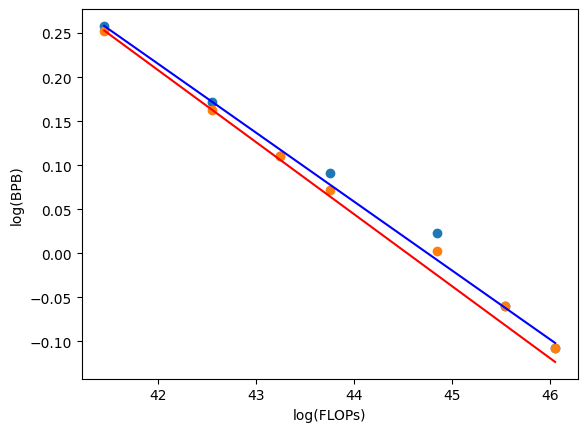

In [186]:
import matplotlib.pyplot as plt
import numpy as np

validation_set = "eval/paloma/4chan" # "eval/paloma/dolma-v1_5" # "eval/tony-correct"# "eval/paloma/4chan"
target_set = "eval/deepseek-r1"
# validation_set = target_set
# target_set = validation_set

print(f"Validation set: {validation_set}")
print(f"Target set: {target_set}")


best_idx = df.groupby("flops")[validation_set].idxmin()
best_df = df.loc[best_idx]

y = [np.log(bpb) for bpb in best_df[target_set].to_list()]
x = [np.log(flops) for flops in best_df["flops"].to_list()]

plt.scatter(x, y)

# fit y ≈ m*x + b
m, b = np.polyfit(x[:2], y[:2], deg=1)

# best-fit line
x_line = np.linspace(min(x), max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color="blue")

# second scatter plot

validation_set = "eval/tony-correct"# "eval/paloma/4chan"
target_set = "eval/deepseek-r1"
validation_set = target_set
# target_set = validation_set

print(f"Validation set: {validation_set}")
print(f"Target set: {target_set}")


best_idx = df.groupby("flops")[validation_set].idxmin()
best_df = df.loc[best_idx]

y = [np.log(bpb) for bpb in best_df[target_set].to_list()]
x = [np.log(flops) for flops in best_df["flops"].to_list()]

plt.scatter(x, y)

# fit y ≈ m*x + b
m, b = np.polyfit(x[:2], y[:2], deg=1)

# best-fit line
x_line = np.linspace(min(x), max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color="red")

plt.xlabel("log(FLOPs)")
plt.ylabel("log(BPB)")
plt.show()


x: eval/paloma/4chan
y: eval/tony-correct


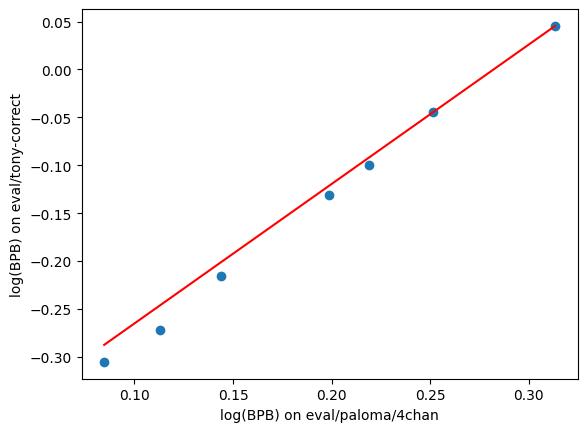

In [185]:
import matplotlib.pyplot as plt
import numpy as np

x_set = "eval/paloma/4chan" # "eval/paloma/dolma-v1_5" # "eval/tony-correct"# "eval/paloma/4chan"
y_set = "eval/tony-correct"

print(f"x: {x_set}")
print(f"y: {y_set}")

best_idx = df.groupby("flops")[x_set].idxmin()
best_df = df.loc[best_idx]

y = [np.log(bpb) for bpb in best_df[y_set].to_list()]
x = [np.log(bpb) for bpb in best_df[x_set].to_list()]

plt.scatter(x, y)

# fit y ≈ m*x + b
m, b = np.polyfit(x[:2], y[:2], deg=1)

# best-fit line
x_line = np.linspace(min(x), max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color="red")

plt.xlabel(f"log(BPB) on {x_set}")
plt.ylabel(f"log(BPB) on {y_set}")
plt.show()


x: eval/paloma/dolma_100_subreddits
y: eval/tony-correct


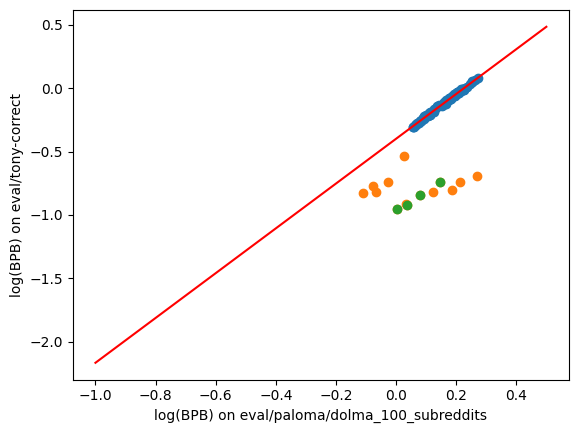

In [182]:
import matplotlib.pyplot as plt
import numpy as np

x_set = "eval/paloma/dolma_100_subreddits" # "eval/paloma/dolma-v1_5" # "eval/tony-correct"# "eval/paloma/4chan"
y_set = "eval/tony-correct"

print(f"x: {x_set}")
print(f"y: {y_set}")

isoflop_df = df[df.index.map(lambda x: isoflop_filter(x))]
hf_df = df[df.index.map(lambda x: not isoflop_filter(x))]
marin_df = df[df.index.map(lambda x: "Qwen" in x and "Base" in x)]

y = [np.log(bpb) for bpb in isoflop_df[y_set].to_list()]
x = [np.log(bpb) for bpb in isoflop_df[x_set].to_list()]

plt.scatter(x, y)

# fit y ≈ m*x + b
m, b = np.polyfit(x, y, deg=1)

# best-fit line
x_line = np.linspace(-1.0, 0.5, 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color="red")

y = [np.log(bpb) for bpb in hf_df[y_set].to_list()]
x = [np.log(bpb) for bpb in hf_df[x_set].to_list()]

plt.scatter(x, y)

y = [np.log(bpb) for bpb in marin_df[y_set].to_list()]
x = [np.log(bpb) for bpb in marin_df[x_set].to_list()]

plt.scatter(x, y)

plt.xlabel(f"log(BPB) on {x_set}")
plt.ylabel(f"log(BPB) on {y_set}")
plt.show()


x: eval/uncheatable_eval/github_cpp
y: eval/tony-correct


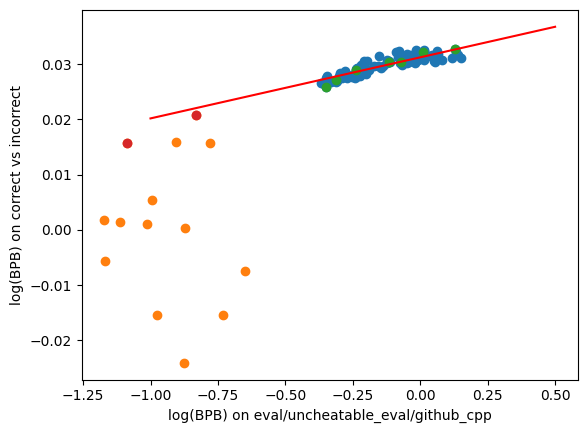

In [150]:
import matplotlib.pyplot as plt
import numpy as np

x_set = "eval/uncheatable_eval/github_cpp" # "eval/paloma/dolma-v1_5" # "eval/tony-correct"# "eval/paloma/4chan"

print(f"x: {x_set}")
print(f"y: {y_set}")

isoflop_df = df[df.index.map(lambda x: isoflop_filter(x))]
hf_df = df[df.index.map(lambda x: not isoflop_filter(x))]
marin_df = df[df.index.map(lambda x: "llama" in x)]

y = [
    np.log(bpb_1) - np.log(bpb_0) 
    for bpb_1, bpb_0 in zip(isoflop_df["eval/tony-correct"].to_list(), isoflop_df["eval/tony-incorrect"].to_list())
]
x = [np.log(bpb) for bpb in isoflop_df[x_set].to_list()]

plt.scatter(x, y)

# fit y ≈ m*x + b
m, b = np.polyfit(x, y, deg=1)

# best-fit line
x_line = np.linspace(-1.0, 0.5, 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color="red")

y = [
    np.log(bpb_1) - np.log(bpb_0) 
    for bpb_1, bpb_0 in zip(hf_df["eval/tony-correct"].to_list(), hf_df["eval/tony-incorrect"].to_list())
]
x = [np.log(bpb) for bpb in hf_df[x_set].to_list()]

plt.scatter(x, y)

best_idx = df.groupby("flops")[validation_set].idxmin()
best_df = df.loc[best_idx]

y = [
    np.log(bpb_1) - np.log(bpb_0) 
    for bpb_1, bpb_0 in zip(best_df["eval/tony-correct"].to_list(), best_df["eval/tony-incorrect"].to_list())
]
x = [np.log(bpb) for bpb in best_df[x_set].to_list()]

plt.scatter(x, y)

y = [
    np.log(bpb_1) - np.log(bpb_0) 
    for bpb_1, bpb_0 in zip(marin_df["eval/tony-correct"].to_list(), marin_df["eval/tony-incorrect"].to_list())
]
x = [np.log(bpb) for bpb in marin_df[x_set].to_list()]

plt.scatter(x, y)

plt.xlabel(f"log(BPB) on {x_set}")
plt.ylabel(f"log(BPB) on correct vs incorrect")
plt.show()

In [139]:
import fsspec

path = "/Users/rohith/Desktop/MATH/combined.jsonl.gz"

with fsspec.open(path, "rt", compression="infer") as f:
    for line in f:
        data = json.loads(line)
        print(data)
        break


{'input': 'A dog takes 4 leaps for every 5 leaps of a hare but 3 leaps of a dog are equal to 4 leaps of the hare. Compare their speeds. Put your final answer in \\boxed{...}.', 'picked': 'The problem describes a dog and a hare comparing their speeds based on their leaps.\n\nThe problem states, "A dog takes 4 leaps for every 5 leaps of a hare." This means that when the dog makes 4 jumps, the hare makes 5. It is not initially clear whether this refers to them moving at the same time or just in terms of the number of leaps. This likely relates to the rate at which they leap, that is, how often they leap.\n\nThen it states, "3 leaps of a dog are equal to 4 leaps of the hare." Thus, 3 dog leaps = 4 hare leaps. This is important and likely relates to the distance each covers per leap. \n\nThe goal is to find the ratio of their speeds. Speed is distance over time, so if the distance each covers in a certain amount of time can be found, their speeds can be compared.\n\nDenote the distance of o